什么是Agent？ langchian 官网有一句话： agent = LLM + harness

以大语言模型为推理与决策核心，结合记忆、工具 与环境交互能力，能够自主进行决策规划并执行复杂任务

Agent的关键能力：
- 理解用户问题
- 如何拆解问题
- 判断需要哪些工具
- 需要调用哪些工具
- 如何利用好 工具结果 生成回答并推进任务

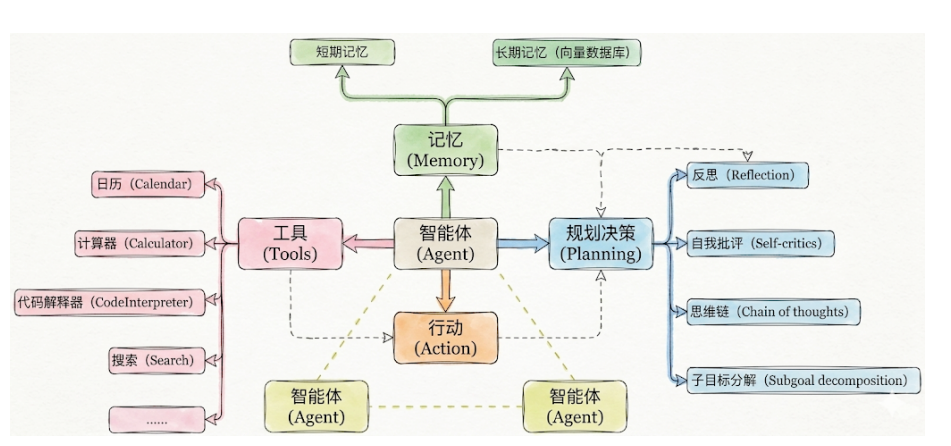


Agent框架实现多轮工具的循环机制（根据模型返回的tool_calls），但是否需要调用工具，是由大模型决策的。

这种 调用模型-》判断是否循环工具-》执行工具-》在判断是否需要工具 -》 模型再调用
广义上也是 ReAct，更准确的叫 Tool Calling Agent Loop。是下一代ReAct






In [3]:
from json import tool
from traceback import print_tb

import rprint
from langchain.agents import create_agent

from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv
from langchain_core.tools import Tool

load_dotenv(verbose=True)

api_key = os.getenv("COMPANY_API_KEY")
base_url = os.getenv("COMPANY_BASE_URL")

llm = init_chat_model(
    model="glm-5.3-flash",
    model_provider="openai",
    api_key=api_key,
    base_url=base_url
)

graph = create_agent(
    model=llm,
    tools=[],
    system_prompt="你是一个通用智能体"

)

response = graph.invoke(
    {
        "messages": [{"role": "user", "content": "北京天气怎么样？"}]
    }
)
print(response)





{'messages': [HumanMessage(content='北京天气怎么样？', additional_kwargs={}, response_metadata={}, id='6d211a4a-b5a6-460b-885d-ec37007e4dd0'), AIMessage(content='抱歉，我无法获取实时天气信息。要了解北京当前的天气情况，建议您：\n\n**查询方式：**\n- 📱 天气类App：墨迹天气、彩云天气等\n- 🌐 网站：中国天气网（weather.com.cn）\n- 🔍 直接在搜索引擎搜索“北京天气”\n- 🗣️ 询问手机的语音助手（如Siri、小爱同学等）\n\n**北京气候特点参考：**\n- **春季（3-5月）**：干燥多风，偶有沙尘\n- **夏季（6-8月）**：炎热多雨，7-8月为雨季\n- **秋季（9-11月）**：秋高气爽，最适合出行\n- **冬季（12-2月）**：寒冷干燥，气温可低至-10°C左右\n\n如果您即将去北京旅行，需要我提供一些出行建议吗？', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 368, 'prompt_tokens': 22, 'total_tokens': 390, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': 0, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': 0, 'text_tokens': 0}, 'usage_semantic': 'openai', 'usage_source': 'anthropic', 'billing_usage': {'sou

In [15]:
from langchain.agents import create_agent

from langchain.chat_models import init_chat_model
from rich import print as rprint
import os
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from langchain.tools import tool

load_dotenv(verbose=True)

api_key = os.getenv("COMPANY_API_KEY")
base_url = os.getenv("COMPANY_BASE_URL")

llm = init_chat_model(
    model="glm-5.3-flash",
    model_provider="openai",
    api_key=api_key,
    base_url=base_url
)

# Agent绑定工具
# 可以单独调用
web_search = TavilySearch()
result = web_search.invoke("帮我搜索特斯拉最近的股票")
# print(result)

@tool
def get_weather(city:str):
    """
    天气查询工具
    Args：
        city: 城市名称
    """
    return f"{city}的天气很棒！"


graph = create_agent(
    model=llm,
    tools=[web_search,get_weather],
    system_prompt="你是一个通用智能体"
)

response = graph.invoke(
    # {
    #     "messages": [{"role": "user", "content": "2025年的诺贝尔文学奖是谁？"}]
    # }
    {
        "messages": [{"role": "user", "content": "杭州的天气怎么样？"}]
    }
)

rprint(response)
# 返回的是一个messages列表，其中会包含 各种角色的消息类型，取最后一条模型的消息
print(response['messages'][-1].content)





{
    'messages': [
        HumanMessage(
            content='杭州的天气怎么样？',
            additional_kwargs={},
            response_metadata={},
            id='16ac80dd-3353-4373-99d1-fd2384bb3010'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 37,
                    'prompt_tokens': 1707,
                    'total_tokens': 1744,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': None,
                        'text_tokens': 0,
                        'image_tokens': 0
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': 0,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': 0,
                        'text_tokens': 0
                    },
                    'usage_semantic': 'openai',
                    'usage_source': 'anthropic',
                    'billing_usage': {
                        'source': 'claude_messages',
                        'semantic': 'anthropic',
                        'claude_usage': {
                            'input_tokens': 1707,
                            'cache_creation_input_tokens': 0,
                            'cache_read_input_tokens': 0,
                            'output_tokens': 37,
                            'claude_cache_creation_5_m_tokens': 0,
                            'claude_cache_creation_1_h_tokens': 0,
                            'server_tool_use': {'web_search_requests': 0}
                        }
                    },
                    'input_tokens': 1707,
                    'output_tokens': 0,
                    'input_tokens_details': None,
                    'claude_cache_creation_5_m_tokens': 0,
                    'claude_cache_creation_1_h_tokens': 0
                },
                'model_provider': 'openai',
                'model_name': 'glm-5.3-flash',
                'system_fingerprint': None,
                'id': 'msg_20260927200436f70ddae691614d36',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0e2c0-b947-7973-9d1c-2345088aa926-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '杭州'},
                    'id': 'call_69729aa1d62044b38f6c2e37',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1707,
                'output_tokens': 37,
                'total_tokens': 1744,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content='杭州的天气很棒！',
            name='get_weather',
            id='aa845219-bdfb-41d4-b078-e644581bdff4',
            tool_call_id='call_69729aa1d62044b38f6c2e37'
        ),
        AIMessage(
            content='杭州的天气很棒！☀️\n\n目前杭州天气情况良好，很适合外出活动。如果您计划出门，无论是游览西湖、灵
隐寺还是其他景点，都是不错的选择。\n\n需要我帮您查询其他城市的天气吗？',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 77,
                    'prompt_tokens': 1730,
                    'total_tokens': 1807,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': None,
                  

杭州的天气很棒！☀️

目前杭州天气情况良好，很适合外出活动。如果您计划出门，无论是游览西湖、灵隐寺还是其他景点，都是不错的选择。

需要我帮您查询其他城市的天气吗？
